# Data analysis project: Trust Signals vs Price, what distinguish Best Sellers on Amazon E-Commerce Marketplace

This project investigates whether trust signals (ratings and reviews) or price variation have a stronger association with sales performance among Amazon best-selling products. Using web-scraped data from 6,000 Amazon Best Sellers, the analysis explores how social proof and pricing strategies relate to sales intensity in a competitive marketplace.

## 1. Load Data
Import the necessary libraries and load the dataset used for the analysis.

In [13]:
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import re

The scraped data is distributed across multiple CSV files. 
These files are loaded from the folder path and combined into a single dataframe to create a unified dataset for analysis.

In [ ]:
folder_path = "../data/raw"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

df = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)

print(df.head())

   page  rank                                              title   price  \
0     1     1                                           no title     NaN   
1     1     2  d'alba Italian White Truffle First Spray Serum...  €16.24   
2     1     3  Maybelline New York Black Mascara for Extremel...   €9.08   
3     1     4  d'alba Italian White Truffle Double Serum All-...  €23.99   
4     1     5  Bionoble Organic Castor Oil, 50 ml, 100% Pure,...   €9.98   

   reviews_count              rating        asin  \
0          117.0  4.4 out of 5 stars  B0BV9K8BXT   
1        33086.0  4.4 out of 5 stars  B0BFQ9RD5B   
2        73113.0  4.4 out of 5 stars  B08P4YPB8Q   
3         3393.0  4.3 out of 5 stars  B09SZ5JX2Y   
4        59872.0  4.4 out of 5 stars  B08D6G78W6   

                                                 url  rank_filled category  \
0  https://www.amazon.de/-/en/OOTD-Retinol-Sheet-...          1.0   beauty   
1  https://www.amazon.de/-/en/dalba-Spraying-Mois...          2.0   beauty

Explore shapes and variables in dataset

In [15]:
df.shape

(5980, 14)

In [16]:
df.dtypes

page                 int64
rank                 int64
title               object
price               object
reviews_count      float64
rating              object
asin                object
url                 object
rank_filled        float64
category            object
market_place        object
bought_number       object
date                object
bought_number_2     object
dtype: object

In [23]:
df.isnull().sum()

page                  0
rank                  0
title                 0
price                32
reviews_count        25
rating               25
asin                  0
url                   0
rank_filled        2392
category              0
market_place          0
bought_number       828
date               3588
bought_number_2    4876
dtype: int64

## 2. Data Preparation

Before conducting the analysis, the dataset is cleaned and transformed.  
This includes handling missing values, converting data types, and creating additional variables used in the analysis.

Steps include:
- Removing missing values
- Checking for duplicates
- Converting price, reviews count, units sold, rating to correct numeric format
- Mapping category paths to category names


In [17]:
# Drop rows with missing values in 'price', 'reviews_count', and 'rating' and drop unnecessary columns
df = df.dropna(subset=['price','reviews_count','rating'])
df = df.drop(columns=['page','rank_filled','date'])

# Rename columns in order to be more descriptive and consistent with the data they contain:
df = df.rename(columns={'category':'category_path'})

In [18]:
# Mapping 'market_place' values to lowercase
df['market_place'].unique()


array(['de', 'co.uk', 'es', 'it', 'fr', 'DE'], dtype=object)

In [19]:
df['market_place'].replace({'DE':'de'},inplace=True)

/var/folders/z1/hpkmqfl54717zbjq651n7__40000gn/T/ipykernel_31677/540537630.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['market_place'].replace({'DE':'de'},inplace=True)


In [20]:
# Clean the column price:
df["price"] = (
    df["price"]
        .str.replace(r"[^\d.]", "", regex=True)   # remove everything except digits and dot
        .astype(float) )                           # convert to float

In [21]:
# Clean the column rating:
df["rating"] = df["rating"].str[:3].astype(float)

In [ ]:
#Cleaning bought_number columns:
def transfer_number(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()

    # keep only the leading number part (like 900, 4k, 1.2k)
    m = re.search(r'(\d+(?:\.\d+)?)\s*([km]?)', s)
    if not m:
        return np.nan

    num = float(m.group(1))
    suffix = m.group(2)

    if suffix == 'k':
        num *= 1000
    elif suffix == 'm':
        num *= 1_000_000

    return int(num)

df['bought_number'] = df['bought_number'].apply(transfer_number)
df['bought_number_2'] = df['bought_number_2'].apply(transfer_number)

def replace_number(row):
    if row['bought_number'] == 0:
        return row['bought_number_2']
    return row['bought_number']

df['bought_number'] = df.apply(replace_number, axis=1)

df = df.drop(columns='bought_number_2')
# Rename columns in order to be more descriptive and consistent with the data they contain:
df = df.rename(columns={'bought_number' : 'units_sold'})

In [25]:
df.head()

,rank,title,price,reviews_count,rating,asin,url,category_path,market_place,units_sold
1,2,d'alba Italian White Truffle First Spray Serum...,16.24,33086.0,4.4,B0BFQ9RD5B,https://www.amazon.de/-/en/dalba-Spraying-Mois...,beauty,de,8000.0
2,3,Maybelline New York Black Mascara for Extremel...,9.08,73113.0,4.4,B08P4YPB8Q,https://www.amazon.de/-/en/Maybelline-Mascara-...,beauty,de,9000.0
3,4,d'alba Italian White Truffle Double Serum All-...,23.99,3393.0,4.3,B09SZ5JX2Y,https://www.amazon.de/-/en/dalba-Italian-Treat...,beauty,de,3000.0
4,5,"Bionoble Organic Castor Oil, 50 ml, 100% Pure,...",9.98,59872.0,4.4,B08D6G78W6,https://www.amazon.de/-/en/Bionoble-Organic-Ey...,beauty,de,3000.0
5,6,"Ninabella® Organic Hair Brush, No Tugging, Pro...",9.99,54796.0,4.8,B08P7DK62W,https://www.amazon.de/-/en/Ninabella%C2%AE-Org...,beauty,de,1000.0


### Category Mapping

To make the dataset easier to analyze, the `category_path` variable is mapped to a readable `category_name` using the reference file `categories.csv`.

Steps performed:

- Merge the dataset with `categories.csv` to map each `category_path` to its corresponding `category_name`.

- Check for null values in the `category_name` column after the merge to ensure that all `category_path` values were successfully matched.

- If null values appear, this indicates that some `category_path` values do not have a corresponding `category_name` in `categories.csv`, which may suggest missing entries or inconsistencies in the category mapping data.

In [26]:
folder_path = "../data/clean"
df_category=pd.read_csv(folder_path + '/categories.csv')
df = df.merge(df_category, on=['category_path','market_place'], how='left')

In [ ]:
df[df['category_name'].isnull()] 

,rank,title,price,reviews_count,rating,asin,url,category_path,market_place,units_sold,category_name


In [ ]:
#df.to_csv('path')  #save the cleaned data to a new csv file

Drop rows with missing values in 'units_sold' and remove rows where 'units_sold' is 0 for better analysis of the relationship between units sold and other variables.

In [ ]:
df = df.dropna(subset='units_sold')
df = df[~(df['units_sold'] == 0)]

## 3. Exploratory Data Analysis

This section explores the main characteristics of the dataset to better understand the distribution and relationships between key variables before conducting the main analysis.

3.1. Correlation Analysis

- We compute a correlation matrix between the main numeric variables: `units_sold`, `price`, `reviews_count`,`rating` 


3.2. Distribution of Key Variables

- We examine the distributions of: `units_sold`,`price`,`reviews_count`,`rating`

- This helps identify skewness, spread, and potential outliers in the dataset.

3.3. Log Transformation for Skewed Variables

- The variables `units_sold`, `price`, and `reviews_count` show strong right skewness, which is common in e-commerce data.

- To improve visualization and analysis, we apply a log transformation to these variables.  
Log scaling reduces skewness and makes patterns in the data easier to interpret.

### Calculate the correlation matrix for numeric columns and visualize it using a heatmap:

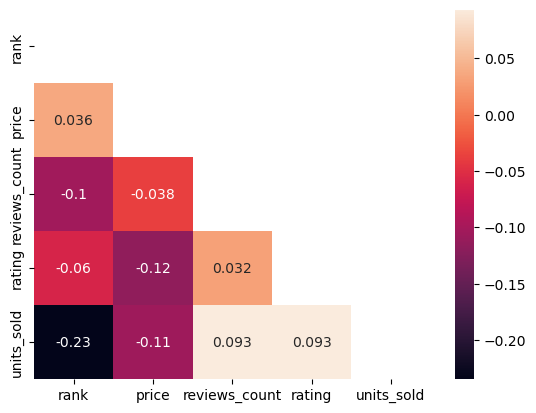

In [ ]:
df_numeric = df.select_dtypes(include='number')
corr_matrix = df_numeric.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    mask=np.triu(np.ones_like(corr_matrix, dtype=bool))
)

plt.show()

### Visualize the distribution of key numeric variables using histograms:

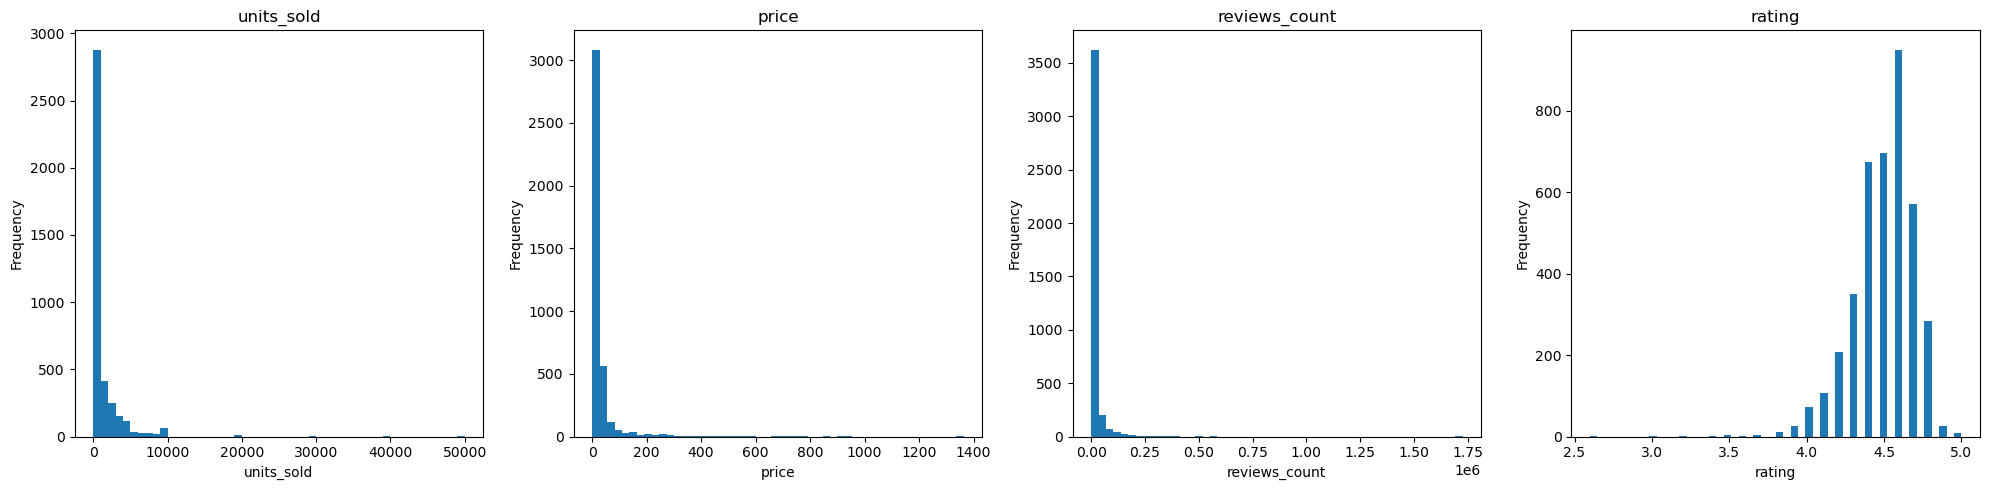

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))

variables = ["units_sold", "price", "reviews_count", "rating"]

for ax, var in zip(axes, variables):
    ax.hist(df[var], bins=50)
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Apply log transformation to `units_sold`,`price`,`reviews_count`:

In [ ]:
df['log_reviews'] = np.log(df['reviews_count'] + 1)
df["log_price"] = np.log(df["price"])
df["log_units_sold"] = np.log(df["units_sold"])

Visualize the distribution of the log-transformed variables using histograms:

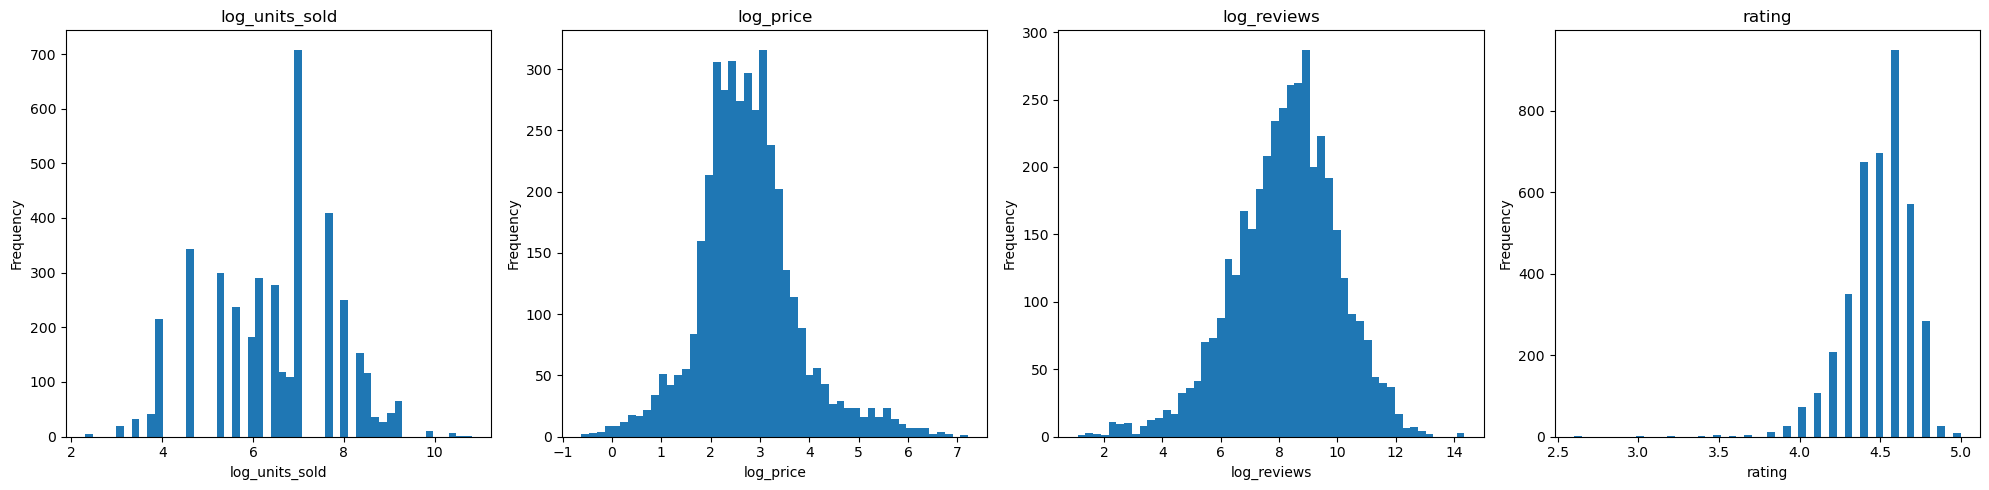

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(20,5))

variables = ["log_units_sold", "log_price", "log_reviews", "rating"]

for ax, var in zip(axes, variables):
    ax.hist(df[var], bins=50)
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In this project, applying log transformation to `units_sold`, `price`, and `reviews_count` helps reduce right skewness and make relationships between variables easier to interpret, particularly in preparation of regression analysis.

In [ ]:
#Save the cleaned data with log transformations to a new csv file for further analysis.
#df.to_csv('path')  --- IGNORE ---

## 4. Analysis

This section investigates the main research questions of the project, focusing on how trust signals, pricing strategies, and competitive dynamics relate to the performance of Amazon Best Sellers.

### 4.1 Trust Signals vs Sales

This analysis examines whether customer reviews and ratings are associated with product sales performance.

A heatmap to visualize the correlation between numeric variables after log transformation, including `log_units_sold`, `log_price`, `log_reviews`, and `rating`.

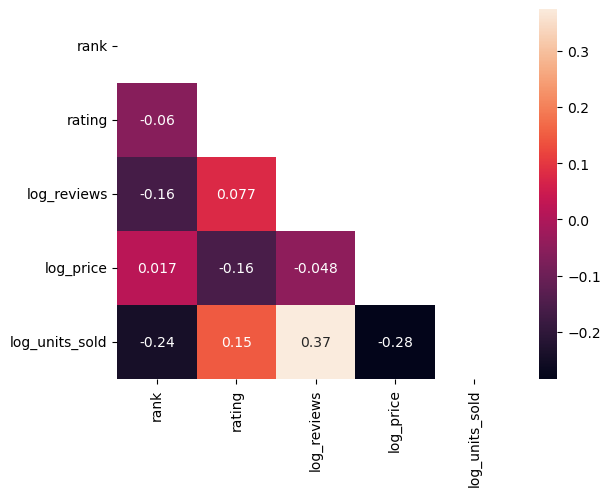

In [ ]:
df_numeric = df.select_dtypes(include='number').drop(columns=['reviews_count','price','units_sold'])
corr_matrix = df_numeric.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    mask=np.triu(np.ones_like(corr_matrix, dtype=bool))
)

plt.show()

### Key Insight: Logging revealed the true economic relationships:

- Reviews are a strong driver (0.37): Social proof matters a lot.

- Price has clear negative elasticity (-0.28): Higher price → lower sales.

- Rank still meaningful (-0.24): Logical marketplace signal.

- Rating has modest effect (0.15): Small but positive.

### 4.2 Price Elasticity by Category

This section examines whether price sensitivity differs across product categories by estimating price elasticity of demand.

Price elasticity measures how strongly sales respond to changes in price. Categories with larger absolute elasticity are more price-sensitive, while those closer to zero are less affected by price.

### Methodology

We estimate price elasticity using a log–log regression between price and units sold:

$$
\log(units\_sold) = \beta_0 + \beta_1 \log(price)
$$

The coefficient β₁ represents the price elasticity of demand.

The regression is estimated using `smf.ols` from the `statsmodels` library.

### Interpretation

- β₁ < 0 → higher prices are associated with lower sales  
- Larger |β₁| → stronger price sensitivity  
- β₁ close to 0 → weaker price sensitivity  

Comparing elasticity estimates across categories reveals whether some markets are more price-driven than others.

Run the initial regression model to analyze how other variables relate to log_units_sold

In [ ]:
df["log_units_sold"] = np.log(df["units_sold"])
df["log_price"] = np.log(df["price"])
df["log_reviews"] = np.log(df["reviews_count"] + 1)

model = smf.ols(
    "log_units_sold ~ log_price + log_reviews + rating + rank + C(category_name) + C(market_place)",
    data=df).fit(cov_type="HC3")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_units_sold   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.651
Method:                 Least Squares   F-statistic:                     408.7
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:47:19   Log-Likelihood:                -4883.4
No. Observations:                3998   AIC:                             9815.
Df Residuals:                    3974   BIC:                             9966.
Df Model:                          23                                         
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

Examine whether the relationship between price and units sold varies across product categories using a second regression model.

In [ ]:
model2 = smf.ols(
    'log_units_sold ~ log_price * C(category_name) + log_reviews + rating + C(market_place)',
    data=df).fit(cov_type="HC3")  
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:         log_units_sold   R-squared:                       0.598
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     201.5
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:48:00   Log-Likelihood:                -5179.8
No. Observations:                3998   AIC:                         1.044e+04
Df Residuals:                    3960   BIC:                         1.067e+04
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

### Price Elasticity by Category

Print the estimated price elasticity for each category based on the regression results from Model 2.

In [37]:
params = model2.params
base = params["log_price"]  

elasticities = {}
for cat in df["category_name"].unique():
    term = f"log_price:C(category_name)[T.{cat}]"
    elasticities[cat] = base + params.get(term, 0.0) 

#df.to_csv('path',index=False)  

elasticities

{'Beauty': np.float64(0.10267232517985747),
 'Baby': np.float64(-0.2160777849098199),
 'Grocery': np.float64(-0.0013561466785243226),
 'Toys & Kids': np.float64(0.029870840014826067),
 'Sports': np.float64(-0.03316028798495965),
 'Handmade': np.float64(0.03418124280559262),
 'Lighting': np.float64(-0.16473616820041967),
 'Auto': np.float64(0.07204393561442779),
 'Kitchen': np.float64(-0.14329677515159076),
 'Industrial': np.float64(-0.2738536507667725),
 'Healthcare': np.float64(-0.18105782852417365),
 'Appliances': np.float64(-0.25618590256431384),
 'Fashion': np.float64(-0.6711569535542063),
 'Electronics': np.float64(-0.03154753331627333),
 'Amazon Devices': np.float64(0.20524920808895422),
 'Computers': np.float64(-0.31882515338189665)}

In [39]:
df_elasticities = pd.DataFrame(list(elasticities.items()), columns=['Category', 'Value'])
df_elasticities.sort_values(by='Value',inplace=True)

#df_elasticities.to_csv('path', index=False) IGNORE ---


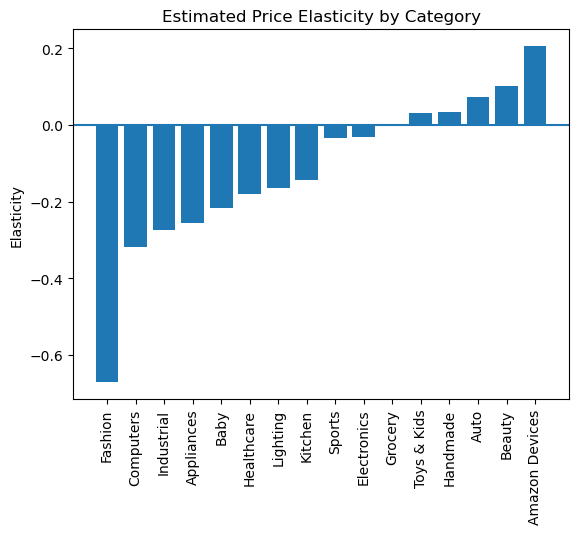

In [42]:
plt.bar(df_elasticities["Category"], df_elasticities["Value"])
plt.axhline(0)
plt.title("Estimated Price Elasticity by Category")
plt.ylabel("Elasticity")
plt.xticks(rotation=90)
plt.show()

### Key Insight:

Price elasticity estimates are relatively low across several categories, suggesting that demand for top-selling products is generally not highly sensitive to price changes.

The Fashion category displays the strongest negative elasticity, indicating higher price sensitivity, while other categories appear less affected by price. This suggests that factors such as reputation and trust signals (reviews and ratings) may play a larger role in driving demand.

### 4.3 Competitive Structure Among Best Sellers

Products are grouped into ranking tiers to examine whether higher-ranked products systematically differ in reviews, price, ratings, and sales.

The ranking groups are defined as:

- Rank 1–10: Top performers  
- Rank 11–50: Mid-tier best sellers  
- Rank 51–100: Lower-ranked best sellers


In [ ]:
# Group products into 3 rank groups

df["rank_group"] = pd.cut(df["rank"],
                          bins=[0,10,50,100],
                          labels=["Top 10","11-50","51-100"])

In [ ]:
# Check the distribution of products across rank groups

print(df["rank_group"].value_counts())

rank_group
51-100    1961
11-50     1595
Top 10     442
Name: count, dtype: int64


Calculate the median reviews count, rating, price, and units sold for each rank group 

In [ ]:

summary = df.groupby("rank_group")[["reviews_count","rating","price","units_sold"]].median()
summary

/var/folders/z1/hpkmqfl54717zbjq651n7__40000gn/T/ipykernel_31677/302396079.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("rank_group")[["reviews_count","rating","price","units_sold"]].median()


,reviews_count,rating,price,units_sold
rank_group,,,,
Top 10,9427.5,4.6,15.185,2000.0
11-50,4752.0,4.5,14.100,900.0
51-100,3163.0,4.5,14.990,600.0


Create a bar charts to visualize the median reviews count, rating, price, and units sold for each rank group.

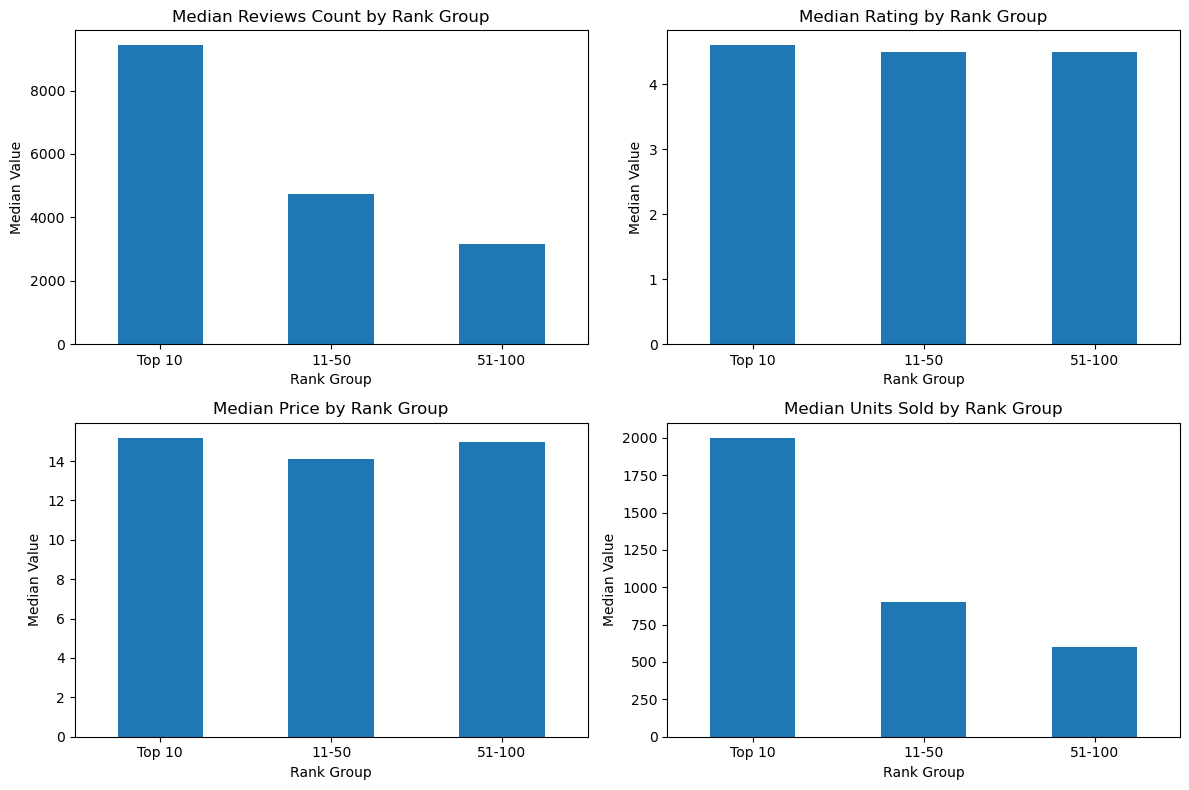

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

summary["reviews_count"].plot(kind="bar", ax=axes[0,0], title="Median Reviews Count by Rank Group")
summary["units_sold"].plot(kind="bar", ax=axes[1,1], title="Median Units Sold by Rank Group")
summary["rating"].plot(kind="bar", ax=axes[0,1], title="Median Rating by Rank Group")
summary["price"].plot(kind="bar", ax=axes[1,0], title="Median Price by Rank Group")

for ax in axes.flatten():
    ax.set_xlabel("Rank Group")
    ax.set_ylabel("Median Value")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Key Insight

The ranking tiers suggest that top-performing products tend to accumulate significantly more reviews, indicating that social proof plays a central role in sustaining top positions within the Best Seller list.